# WebSky Analysis

## CIB + tSZ + noise

In [1]:
### IMPORTS ###

import healpy as hp
import numpy as np
from scipy.interpolate import *
import matplotlib.pyplot as plt

In [2]:
### cosmology.py ###

omegab = 0.049
omegac = 0.261
omegam = omegab + omegac
h      = 0.68
ns     = 0.965
sigma8 = 0.81

c = 3e5

H0 = 100*h
nz = 100000
z1 = 0.0
z2 = 6.0
za = np.linspace(z1,z2,nz)
dz = za[1]-za[0]

H      = lambda z: H0*np.sqrt(omegam*(1+z)**3+1-omegam)
dchidz = lambda z: c/H(z)

chia = np.cumsum(dchidz(za))*dz

zofchi = interp1d(chia,za)

print("Cosmology set up with:")
print(f"omegab = {omegab}")
print(f"omegac = {omegac}")
print(f"omegam = {omegam}")
print(f"h = {h}")
print(f"ns = {ns}")
print(f"sigma8 = {sigma8}")

Cosmology set up with:
omegab = 0.049
omegac = 0.261
omegam = 0.31
h = 0.68
ns = 0.965
sigma8 = 0.81


In [3]:
### PIPELINE ###

# ------------------------------------------------------------------------------------------------------------------------
# 1. Load WebSky Components
# ------------------------------------------------------------------------------------------------------------------------
# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/WebSky_CMB_Mocks/'

# Load the raw tSZ (Compton-y) map from WebSky
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
nside_work = 32
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)

# Create a dictionary to hold the CIB maps at different frequencies
cib_maps = {}

# Create a tuple of frequencies we want to work with (in GHz)
frequencies = [143, 217, 353, 545, 857]

# Load the WebSky CIB maps (which we will treat as proxies for the CMB here, since they have similar statistical properties)
for nu in frequencies:
    cib_map_raw = hp.read_map(path_to_websky + f"cib_nu{nu:04d}.fits")
    cib_map = hp.ud_grade(cib_map_raw, nside_out=nside_work)
    cib_maps[nu] = cib_map
    # You can store these in a dictionary if you want to use them later
    # For now, we will just use one of them as a proxy for the CMB

# Load the WebSky CMB
#cmb_map_raw = hp.read_map(path_to_websky + "cmb.fits")
#cmb_map = hp.ud_grade(cmb_map_raw, nside_out=nside_work)

# ------------------------------------------------------------------------------------------------------------------------
# 2. Define the tSZ frequency scaling function
# ------------------------------------------------------------------------------------------------------------------------
def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    T_cmb = 2.7255 # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

# ------------------------------------------------------------------------------------------------------------------------
# 3. Create the 'Data Cube' at different frequencies
# ------------------------------------------------------------------------------------------------------------------------
data_cube = []

for nu in frequencies:
#for nu in [353, 545]:
    # Get the SZ scaling for this frequency
    g_nu = get_tsz_g(nu) # Use the function from our previous chat
    
    # Map = CMB + g_nu * y_map + Noise
    # (Note: WebSky y-map is usually in dimensionless Compton-y units)
    # T_cmb = 2.7255e6 # to get muK
    noise = np.random.normal(0, 2.0, len(cib_maps[nu])) 
    
    total_map = cib_maps[nu] + (g_nu * y_map * 2.7255e6) + noise
    data_cube.append(total_map)

# Now 'data_cube' is ready for your ILC functions!

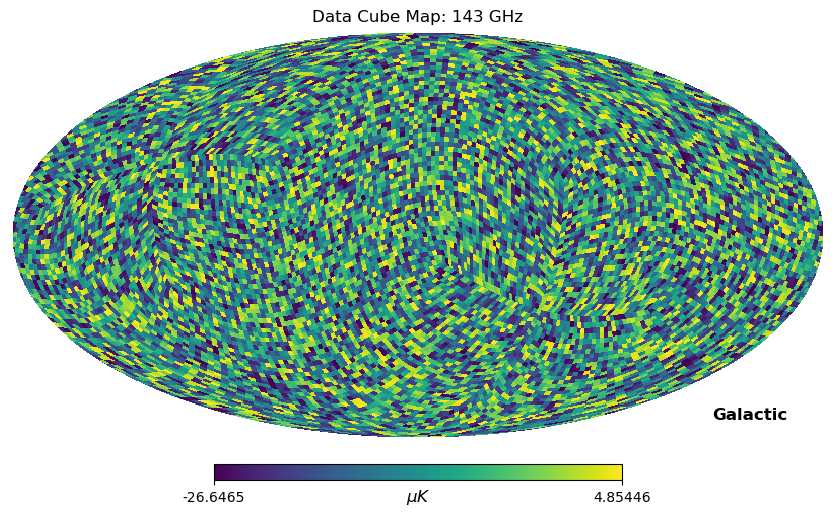

In [4]:
### 1. The Standard Full-Sky View (Mollview) ###

# A single example: map at the first frequency (143 GHz)
hp.mollview(data_cube[0], title=f"Data Cube Map: {frequencies[0]} GHz", unit=r"$\mu K$", norm='hist', cmap='viridis', coord=['C','G'])
plt.show()

# A loop to show all frequencies (uncomment if you want to see them all)
#for i, nu in enumerate(frequencies):
#    hp.mollview(data_cube[i], 
#                title=f"Data Cube Map: {nu} GHz", 
#                unit=r"$\mu K$", 
#                norm='hist', # Helps see the CIB/tSZ structures better
#                cmap='viridis',
#                coord=['C','G']) # Show in Galactic coordinates use coord=['C','G']; to do it in Equatorial use coord=['C','E']
#
#    plt.show()

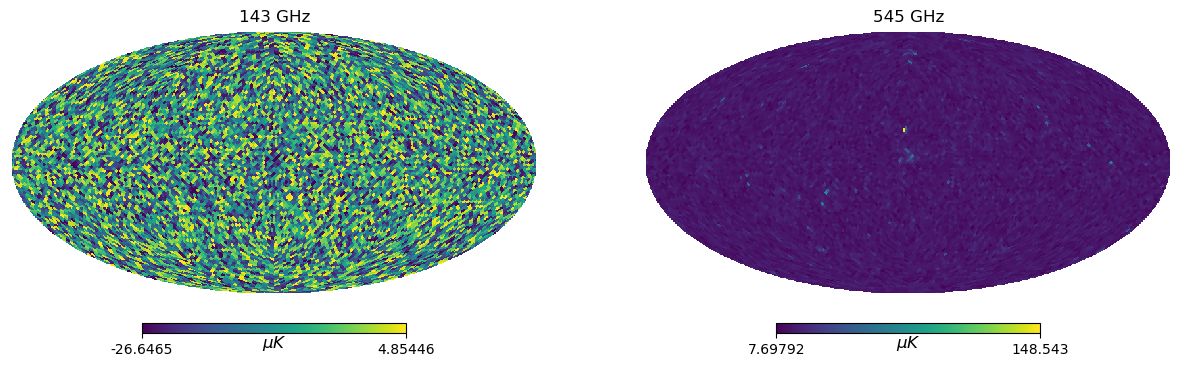

In [5]:
### 2. Side-by-Side Comparison ###

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

plt.axes(ax1)
hp.mollview(data_cube[0], title=f"{frequencies[0]} GHz", hold=True, unit=r"$\mu K$", norm='hist', cmap='viridis')

plt.axes(ax2)
hp.mollview(data_cube[3], title=f"{frequencies[3]} GHz", hold=True, unit=r"$\mu K$")

plt.show()

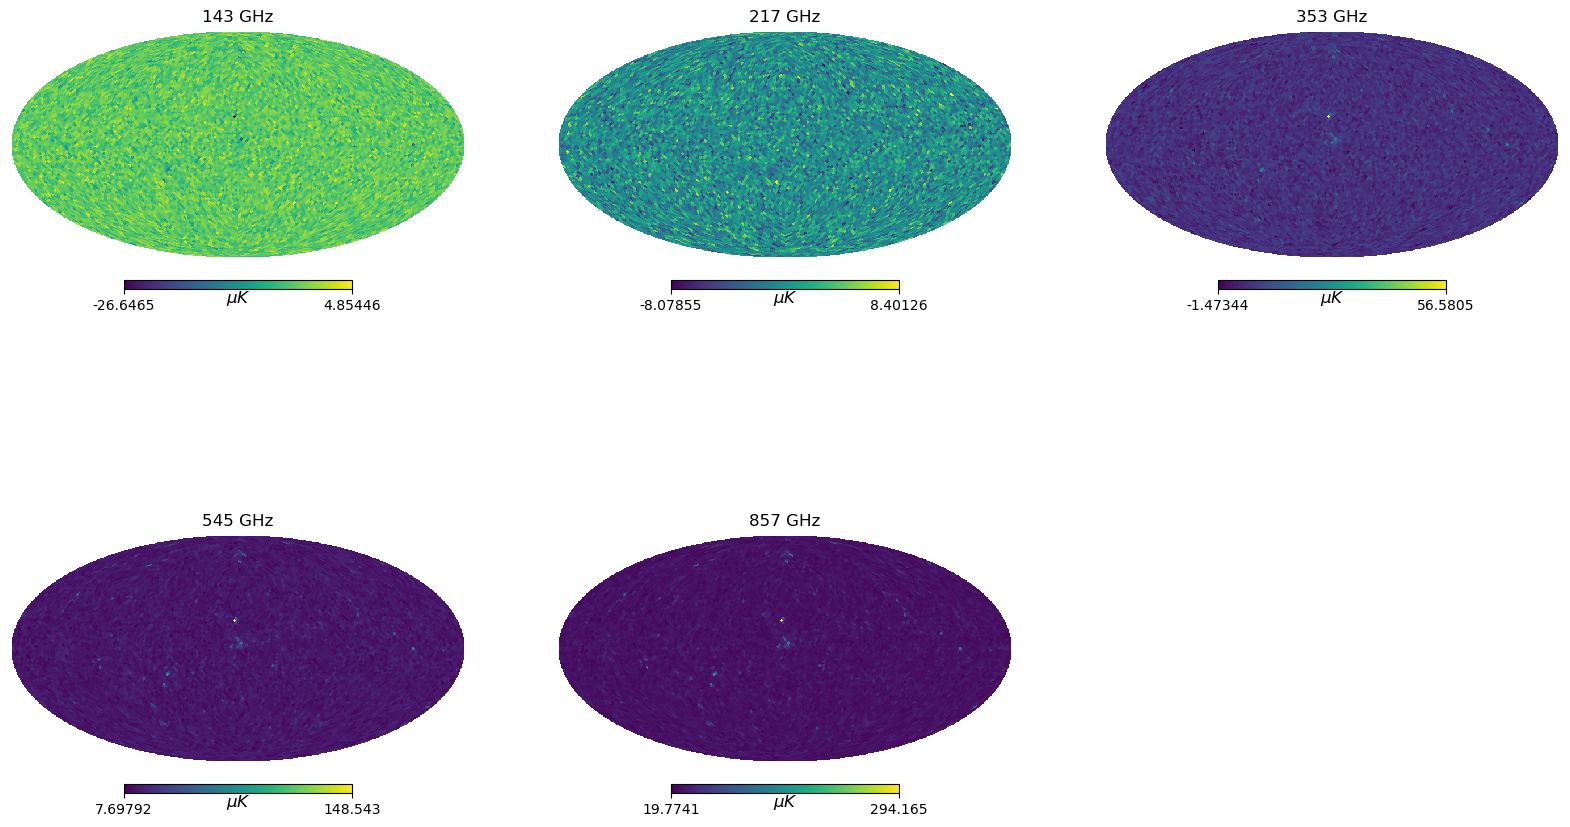

In [6]:
### 3. Comparison for all frequencies ###

fig = plt.figure(figsize=(20, 12))

for i, nu in enumerate(frequencies):
    plt.subplot(2, 3, i+1)
    hp.mollview(data_cube[i], title=f"{nu} GHz", hold=True, unit=r"$\mu K$", cmap='viridis')
    plt.axis('off')
plt.show()

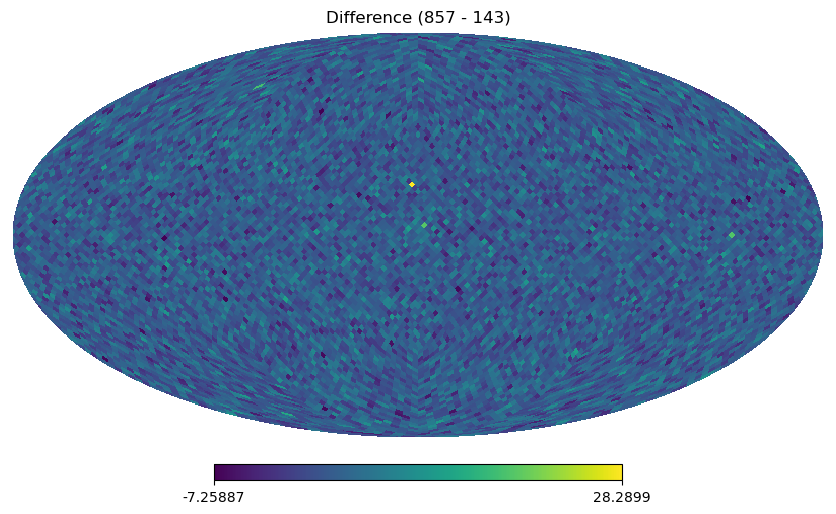

In [7]:
### 4. Checking that the Data Cube is Correctly Constructed ###

# A quick visual check to see if the "randomness" is the same signal
diff01 = data_cube[1] - data_cube[0]
hp.mollview(diff01, title=f"Difference ({frequencies[4]} - {frequencies[0]})")#, norm='hist')

#diff02 = data_cube[2] - data_cube[0]
#hp.mollview(diff02, title=f"Difference ({frequencies[2]} - {frequencies[0]})", norm='hist')

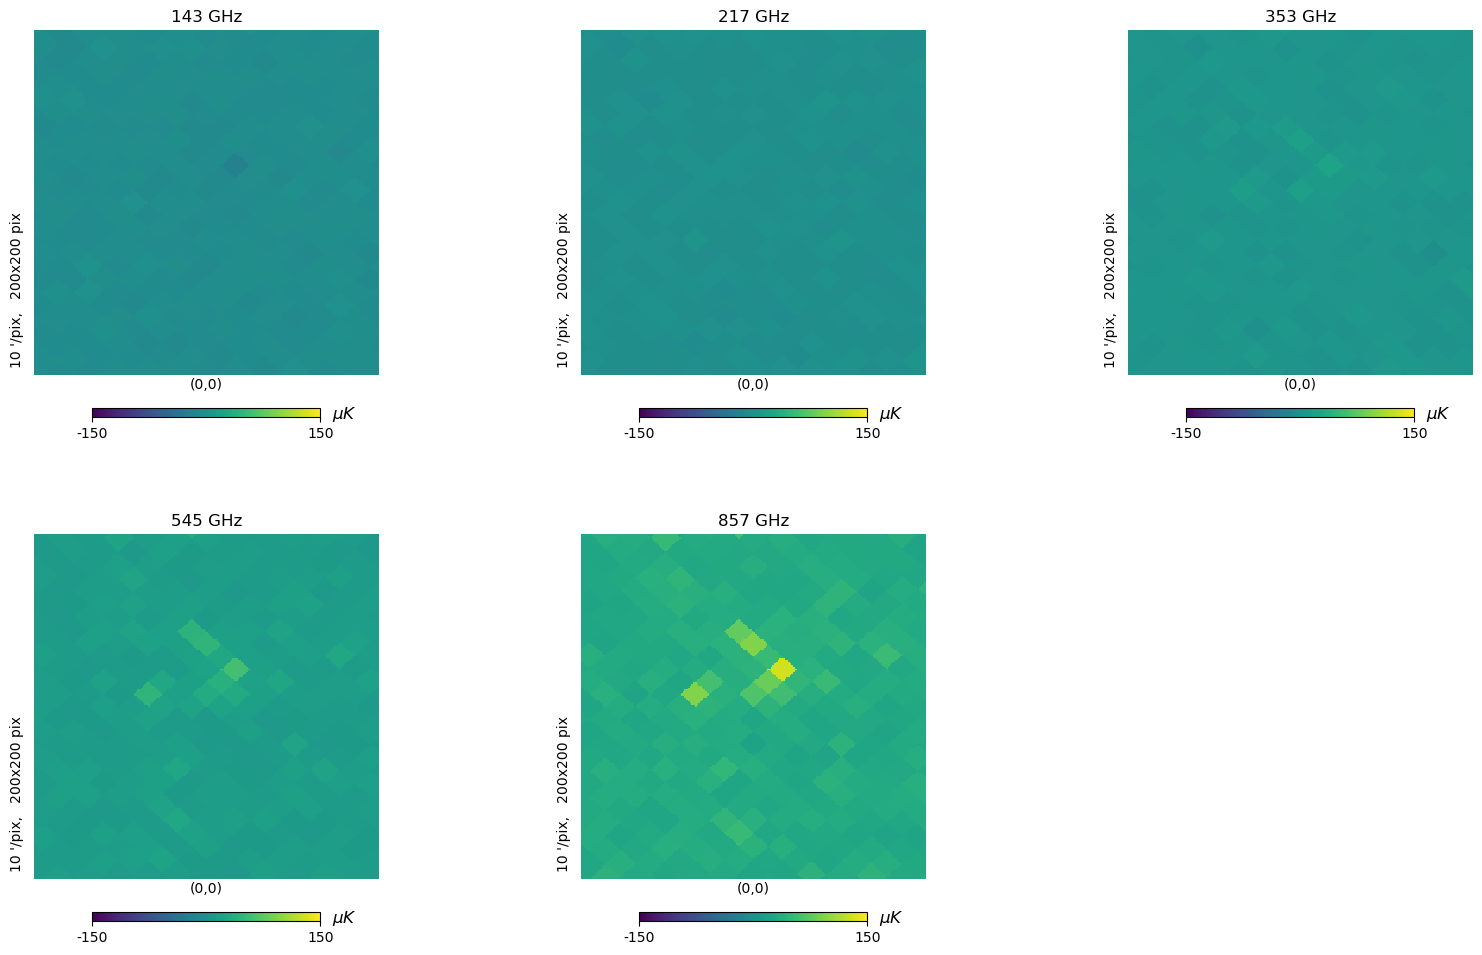

In [8]:
### 5. Gnomonic Comparison (Zoom-in) for all ###

fig = plt.figure(figsize=(20, 12))

# Define the view parameters
# rot: [longitude, latitude] in degrees to center the zoom
# reso: resolution in arcmin per pixel (1.5 is standard for Nside 512-ish)
# xsize: width/height of the patch in pixels
view_params = {'rot': [0, 0], 'reso': 10, 'xsize': 200} 

for i, nu in enumerate(frequencies):
    # We create the subplot using matplotlib notation
    ax = fig.add_subplot(2, 3, i+1)
    
    # Use gnomview for the zoom
    # min/max: manually setting these helps compare the brightness across frequencies
    hp.gnomview(data_cube[i], 
                title=f"{nu} GHz", 
                hold=True, 
                unit=r"$\mu K$", 
                cmap='viridis',
                # norm='hist', # Uncomment if you want to see the CIB fluctuations more clearly
                min=-150, max=150, # Adjust these based on your map's actual values
                **view_params)
    
plt.show()

## WebSky model

See https://github.com/simonsobs/websky_model.git for documentation.

In [1]:
import numpy as np
import websky_model as wm

# load model
wmodel = wm.WebSky(directory_path='/global/project/projectdirs/sobs/v4_sims/mbs/websky/data/',websky_version = 'v0.1', verbose=True)

# read in halo catalogue
hcat  = wmodel.load_halo_catalogue(mmin=0, mmax=np.inf, zmin=0, zmax=np.inf, rmin=0., rmax=np.inf, practical=True)

# project halos onto healpix map. 
# each halo is given a "flux" of weight=constant, or weight=array(len(Nhalo))
hpmap = wmodel.catalogue_to_map(hcat, nside=512, weight=1)

# get cib map filename
fname_cib = wmodel.cib_map_file_name(freq='545')

fname_kappa = wmodel.kappa_map_file_name()

# get compton-y map filename
fname_comptony = wmodel.comptony_map_file_name()

ModuleNotFoundError: No module named 'websky_model'